In [1]:
# coding: utf-8
try:
    import urllib.request
except ImportError:
    raise ImportError('You should use Python 3.x')
import os.path
import gzip
import pickle
import os
import numpy as np



key_file = {
    'train_img':'train-images-idx3-ubyte.gz',
    'train_label':'train-labels-idx1-ubyte.gz',
    'test_img':'t10k-images-idx3-ubyte.gz',
    'test_label':'t10k-labels-idx1-ubyte.gz'
}

dataset_dir = "/content"
save_file = dataset_dir + "/mnist.pkl"

train_num = 60000
test_num = 10000
img_dim = (1, 28, 28)
img_size = 784




def _load_label(file_name):
    file_path = dataset_dir + "/" + file_name

    print("Converting " + file_name + " to NumPy Array ...")
    with gzip.open(file_path, 'rb') as f:
            labels = np.frombuffer(f.read(), np.uint8, offset=8)
    print("Done")

    return labels

def _load_img(file_name):
    file_path = dataset_dir + "/" + file_name

    print("Converting " + file_name + " to NumPy Array ...")
    with gzip.open(file_path, 'rb') as f:
            data = np.frombuffer(f.read(), np.uint8, offset=16)
    data = data.reshape(-1, img_size)
    print("Done")

    return data

def _convert_numpy():
    dataset = {}
    dataset['train_img'] =  _load_img(key_file['train_img'])
    dataset['train_label'] = _load_label(key_file['train_label'])
    dataset['test_img'] = _load_img(key_file['test_img'])
    dataset['test_label'] = _load_label(key_file['test_label'])

    return dataset

def init_mnist():
    #download_mnist()
    dataset = _convert_numpy()
    print("Creating pickle file ...")
    with open(save_file, 'wb') as f:
        pickle.dump(dataset, f, -1)
    print("Done!")
    return dataset

def _change_one_hot_label(X):
    T = np.zeros((X.size, 10))
    for idx, row in enumerate(T):
        row[X[idx]] = 1

    return T


def load_mnist(normalize=True, flatten=True, one_hot_label=False):
    """MNIST 데이터셋 읽기

    Parameters
    ----------
    normalize : 이미지의 픽셀 값을 0.0~1.0 사이의 값으로 정규화할지 정한다.
    one_hot_label :
        one_hot_label이 True면、레이블을 원-핫(one-hot) 배열로 돌려준다.
        one-hot 배열은 예를 들어 [0,0,1,0,0,0,0,0,0,0]처럼 한 원소만 1인 배열이다.
    flatten : 입력 이미지를 1차원 배열로 만들지를 정한다.

    Returns
    -------
    (훈련 이미지, 훈련 레이블), (시험 이미지, 시험 레이블)
    """
    if not os.path.exists(save_file):
        init_mnist()

    with open(save_file, 'rb') as f:
        dataset = pickle.load(f)

    if normalize:
        for key in ('train_img', 'test_img'):
            dataset[key] = dataset[key].astype(np.float32)
            dataset[key] /= 255.0

    if one_hot_label:
        dataset['train_label'] = _change_one_hot_label(dataset['train_label'])
        dataset['test_label'] = _change_one_hot_label(dataset['test_label'])

    if not flatten:
         for key in ('train_img', 'test_img'):
            dataset[key] = dataset[key].reshape(-1, 1, 28, 28)

    return (dataset['train_img'], dataset['train_label']), (dataset['test_img'], dataset['test_label'])


dataset = init_mnist()


Converting train-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting train-labels-idx1-ubyte.gz to NumPy Array ...
Done
Converting t10k-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting t10k-labels-idx1-ubyte.gz to NumPy Array ...
Done
Creating pickle file ...
Done!


In [2]:
dataset

{'train_img': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
 'train_label': array([5, 0, 4, ..., 5, 6, 8], dtype=uint8),
 'test_img': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
 'test_label': array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)}

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T

    x = x - np.max(x) # 오버플로 대책
    return np.exp(x) / np.sum(np.exp(x))
def sigmoid_grad(x):
    return (1.0 - sigmoid(x)) * sigmoid(x)


def numerical_gradient(f, x):
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x)

    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x) # f(x+h)

        x[idx] = tmp_val - h
        fxh2 = f(x) # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2*h)

        x[idx] = tmp_val # 값 복원
        it.iternext()

    return grad


def cross_entropy_error(y, t):

    delta = 1e-7

    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    # 훈련 데이터가 원-핫 벡터라면 정답 레이블의 인덱스로 반환
    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    qq = y[np.arange(batch_size), t]
    ll = np.log(qq+delta)
    ww = -np.sum(ll)
    return ww / batch_size


class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.001):
        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        return y

    # x : 입력 데이터, t : 정답 레이블
    def loss(self, x, t):
        y = self.predict(x)

        return cross_entropy_error(y, t)

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    # x : 입력 데이터, t : 정답 레이블
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])

        return grads

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터 읽기
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

def sample_balanced(x, t, samples_per_class=10):
    # 원-핫 인코딩된 레이블을 정수 레이블로 변환
    labels = np.argmax(t, axis=1)
    sampled_indices = []

    for i in range(10): # 0부터 9까지 클래스
        # 해당 클래스에 속하는 데이터의 인덱스 탐색
        class_indices = np.where(labels == i)[0]
        # 그 중 무작위로 samples_per_class 개수만큼 선택
        chosen = np.random.choice(class_indices, samples_per_class, replace=False)
        sampled_indices.extend(chosen)

    sampled_indices = np.array(sampled_indices)
    # 셔플링하여 특정 클래스가 몰려 있지 않게 함
    np.random.shuffle(sampled_indices)
    return x[sampled_indices], t[sampled_indices]

# 클래스별 10개씩 추출하여 총 100개의 균형 잡힌 훈련 데이터 생성
x_train, t_train = sample_balanced(x_train, t_train, samples_per_class=10)

# 클래스별 1개씩 추출하여 총 10개의 균형 잡힌 테스트 데이터 생성
x_test, t_test = sample_balanced(x_test, t_test, samples_per_class=1)

print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)



(100, 784)
(100, 10)
(10, 784)
(10, 10)


In [17]:
# 훈련 및 테스트 데이터의 클래스별 샘플 개수 확인
train_labels = np.argmax(t_train, axis=1)
test_labels = np.argmax(t_test, axis=1)

train_counts = np.bincount(train_labels, minlength=10)
test_counts = np.bincount(test_labels, minlength=10)

print("=== 훈련 데이터 클래스별 분포 ===")
for cls, count in enumerate(train_counts):
    print(f"Class {cls}: {count}개")

print("\n=== 테스트 데이터 클래스별 분포 ===")
for cls, count in enumerate(test_counts):
    print(f"Class {cls}: {count}개")

=== 훈련 데이터 클래스별 분포 ===
Class 0: 10개
Class 1: 10개
Class 2: 10개
Class 3: 10개
Class 4: 10개
Class 5: 10개
Class 6: 10개
Class 7: 10개
Class 8: 10개
Class 9: 10개

=== 테스트 데이터 클래스별 분포 ===
Class 0: 1개
Class 1: 1개
Class 2: 1개
Class 3: 1개
Class 4: 1개
Class 5: 1개
Class 6: 1개
Class 7: 1개
Class 8: 1개
Class 9: 1개


In [18]:
net = TwoLayerNet(input_size=784, hidden_size=10, output_size=10)

In [12]:
# 하이퍼파라미터
iters_num = 100  # 반복 횟수를 적절히 설정한다.
train_size = x_train.shape[0]
print('train_size',train_size)
batch_size = 10   # 미니배치 크기
learning_rate = 0.1

train_loss_list = []
train_acc_list = []
test_acc_list = []

# 1에폭당 반복 수
iter_per_epoch = max(train_size / batch_size, 1)


from scipy.special import expit


for i in range(iters_num):
    # 미니배치 획득
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 기울기 계산
    grad = net.numerical_gradient(x_batch, t_batch)

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        net.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    loss = net.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    # 1에폭당 정확도 계산
    if i % iter_per_epoch == 0:
        train_acc = net.accuracy(x_train, t_train)
        test_acc = net.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("Step: {:04d}, Loss: {:.5f}, Train Acc: {:.5f}, Test Acc: {:.5f}".format(i+1, loss, train_acc, test_acc))


train_size 100
Step: 0001, Loss: 2.29276, Train Acc: 0.17000, Test Acc: 0.20000
Step: 0011, Loss: 2.13928, Train Acc: 0.17000, Test Acc: 0.20000
Step: 0021, Loss: 2.14815, Train Acc: 0.17000, Test Acc: 0.20000
Step: 0031, Loss: 2.24019, Train Acc: 0.17000, Test Acc: 0.20000
Step: 0041, Loss: 2.14879, Train Acc: 0.17000, Test Acc: 0.20000
Step: 0051, Loss: 2.30597, Train Acc: 0.17000, Test Acc: 0.20000
Step: 0061, Loss: 2.18058, Train Acc: 0.17000, Test Acc: 0.20000
Step: 0071, Loss: 2.19136, Train Acc: 0.17000, Test Acc: 0.20000
Step: 0081, Loss: 2.23113, Train Acc: 0.17000, Test Acc: 0.20000
Step: 0091, Loss: 2.19897, Train Acc: 0.17000, Test Acc: 0.20000


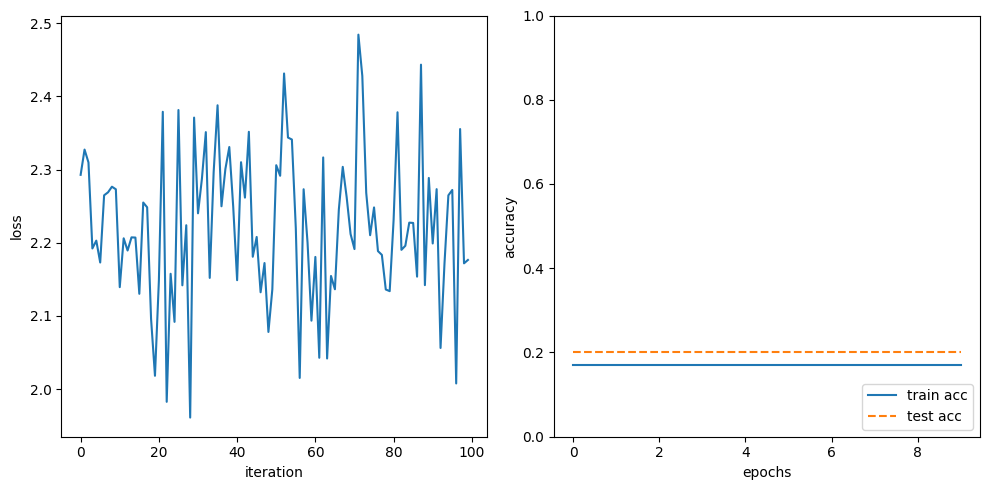

In [19]:
from IPython.core.pylabtools import figsize
# 그래프 그리기
figsize(10, 5)
markers = {'train': 'o', 'test': 's'}
fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

x_loss = np.arange(len(train_loss_list))
ax1.plot(x_loss, train_loss_list)
ax1.set_xlabel("iteration")
ax1.set_ylabel("loss")

x_acc = np.arange(len(train_acc_list))
ax2.plot(x_acc, train_acc_list, label='train acc')
ax2.plot(x_acc, test_acc_list, label='test acc', linestyle='--')
ax2.set_xlabel("epochs")
ax2.set_ylabel("accuracy")
ax2.set_ylim(0, 1.0)
ax2.legend(loc='lower right')
plt.tight_layout()
plt.show()
